## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
data = pd.read_csv('Telecom_Customer_Churn.csv')

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.shape

(7043, 21)

In [5]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
!pip install sweetviz

In [7]:
import sweetviz as sv

# Generate the EDA report
# report = sv.analyze(data)

# Show the report in the notebook
# report.show_html("sweetviz_report.html")

/Users/pulipatipavankumar/softwares/miniconda/envs/ds/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/pulipatipavankumar/softwares/miniconda/envs/ds/lib/python3.11/site-packages/sweetviz/graph.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data Transformation

In [9]:
# Dropping unnecessary columns (if applicable)
data.set_index('customerID', inplace=True)

# Converting 'TotalCharges' to numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce').fillna(0).astype(int)

In [10]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151,Yes


## Label Encoding

In [11]:
#transfomartion categorical to numerical
from sklearn.preprocessing import LabelEncoder

encode = data[['gender', 'Partner', 'Dependents',
         'PhoneService', 'MultipleLines', 'InternetService',
         'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
         'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
        'PaymentMethod', 'Churn']]

le = LabelEncoder()

for column in encode:
  data[column] = le.fit_transform(data[column])

In [12]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29,0
5575-GNVDE,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889,0
3668-QPYBK,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108,1
7795-CFOCW,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840,0
9237-HQITU,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151,1


## Correlation Plot

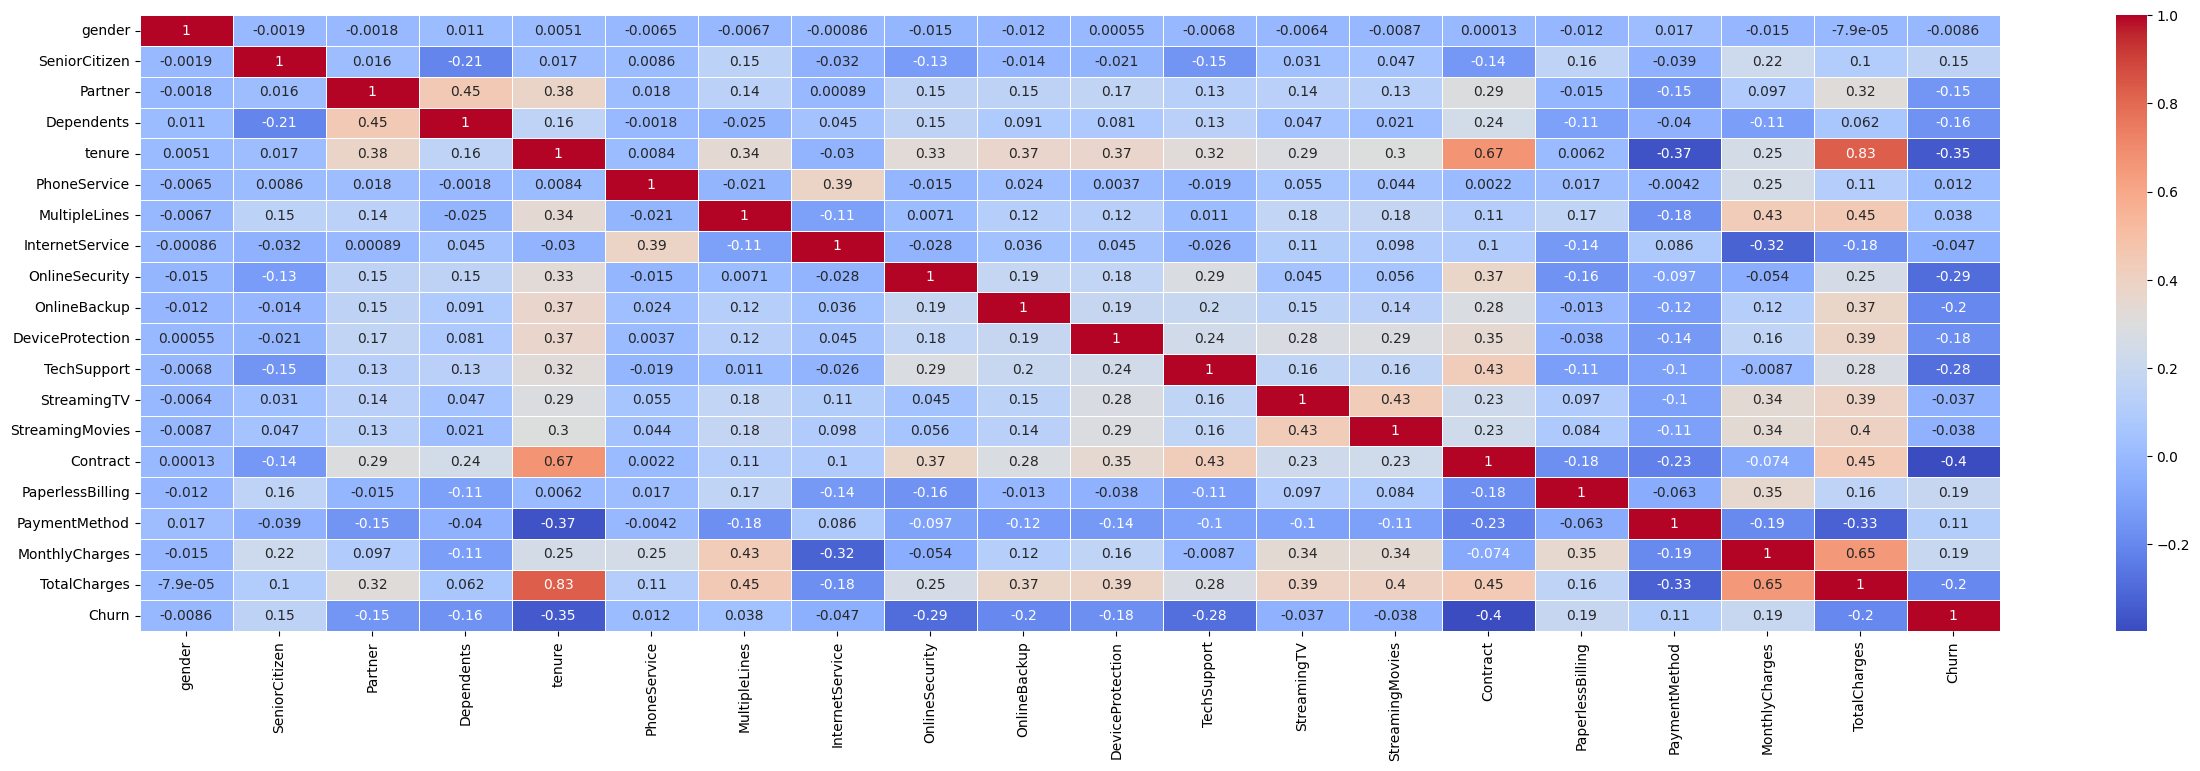

In [13]:
plt.figure(figsize=(30, 8))
sns.heatmap(data.corr(), annot=True, linewidths=0.5, cmap='coolwarm')
plt.show()

As we can seen figure in above, there are five column that have "positive" correlation on the variable object, that is `Churn`

## Build DT

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix

In [15]:
X = data[['PhoneService','MultipleLines','PaperlessBilling','PaymentMethod','MonthlyCharges']]
y = data['Churn']

In [16]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Train the Decision Tree Classifier
dt = DecisionTreeClassifier(criterion="entropy",random_state=42)
dt.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

## DT Model Evaluation

In [18]:
# Predict on training and testing data
train_preds = dt.predict(x_train)
test_preds = dt.predict(x_test)

In [19]:
# Calculate accuracy
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, test_preds)

In [20]:
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9359
Testing Accuracy: 0.7012


## Confusion Matrix

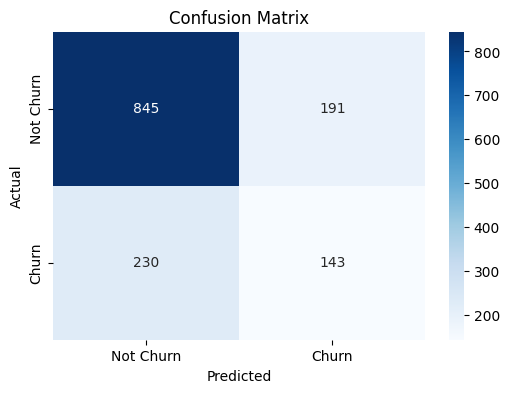

In [21]:
# confusion metrics

# Compute confusion matrix
cm = confusion_matrix(y_test, test_preds)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Churn", "Churn"], yticklabels=["Not Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

- True Negative (`TN`): Correctly predicted negative class (Actual = `Not Churn`, Predicted = `Not Churn`)
- False Positive (`FP`): Incorrectly predicted as positive (Actual = `Not Churn`, Predicted = `Churn`)
- False Negative (`FN`): Incorrectly predicted as negative (Actual = `Churn`, Predicted = `Not Churn`)
- True Positive (`TP`): Correctly predicted positive class (Actual = `Churn`, Predicted = `Churn`)

## Classification Report

In [22]:
# classification report
print("Classification Report (Testing Data):\n")
print(classification_report(y_test, test_preds))

Classification Report (Testing Data):

              precision    recall  f1-score   support

           0       0.79      0.82      0.80      1036
           1       0.43      0.38      0.40       373

    accuracy                           0.70      1409
   macro avg       0.61      0.60      0.60      1409
weighted avg       0.69      0.70      0.70      1409



- The model overfits the training data, as seen by the large gap between training (93.59%) and testing accuracy (70.12%).

- The model performs well on predicting Non-Churn (class 0), but struggles with predicting Churn (class 1), as indicated by the low precision and recall for churn.

- The class imbalance (more Non-Churn instances than Churn) is likely contributing to the model's poor performance on the Churn class.

- Consider using techniques like SMOTE (Synthetic Minority Over-sampling Technique) or class-weight adjustments to handle the class imbalance and explore hyperparameter tuning or regularization to reduce overfitting.

## PLot Decision Tree

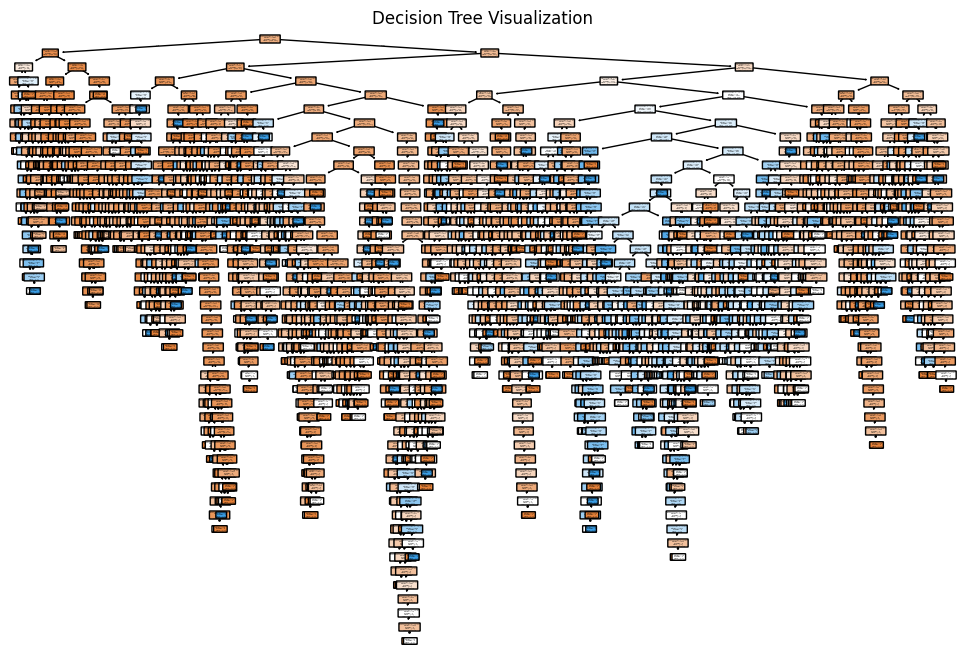

In [23]:
from sklearn.tree import plot_tree

# Visualize the decision tree
plt.figure(figsize=(12, 8))
plot_tree(dt, filled=True, feature_names=x_train.columns, class_names=["Not Churn", "Churn"], rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

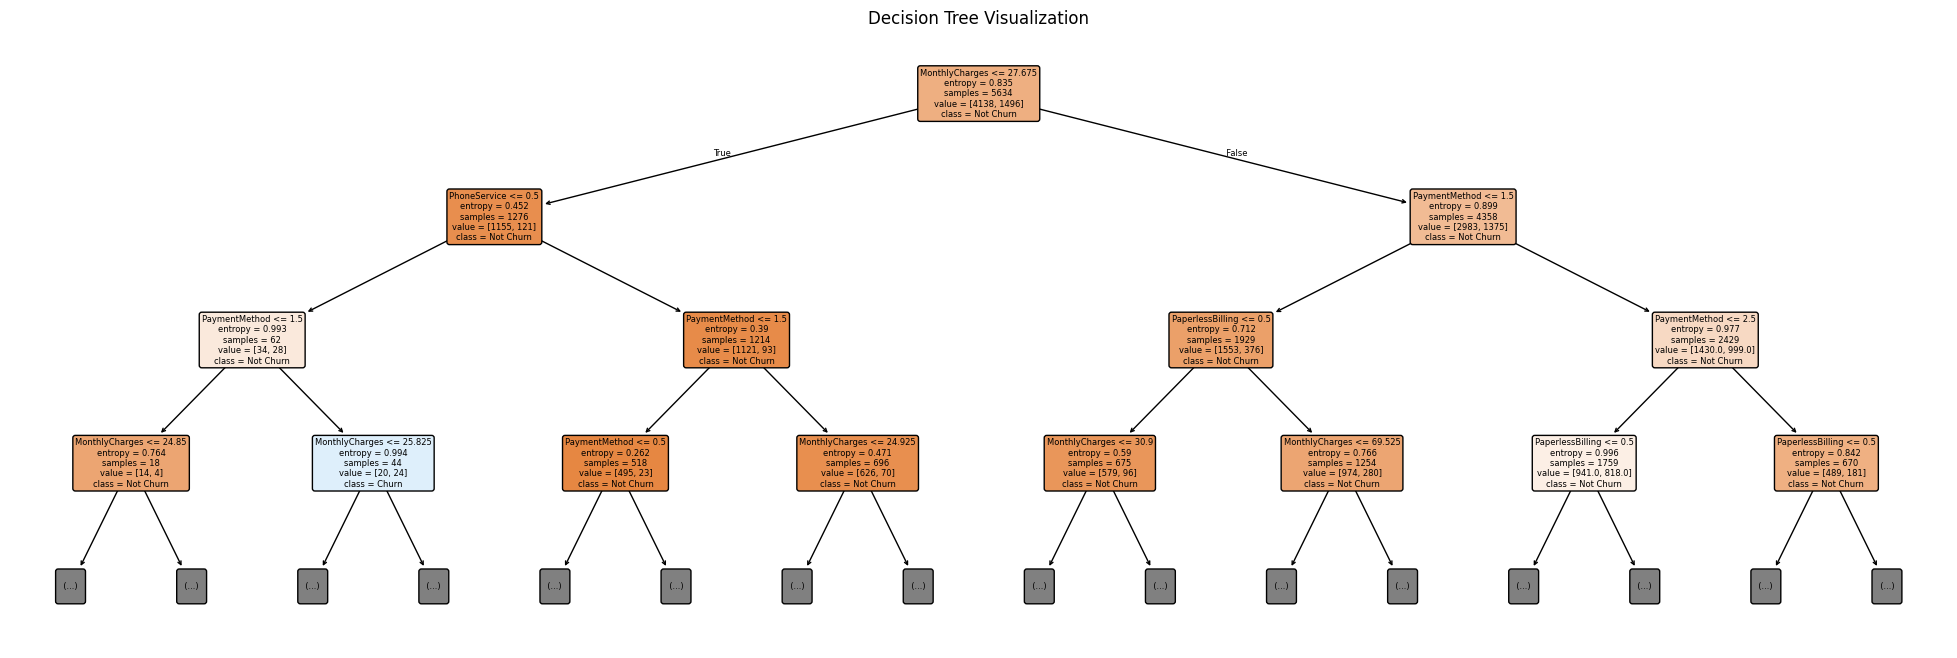

In [24]:
from sklearn.tree import plot_tree

# Visualize the decision tree
plt.figure(figsize=(25, 8))
plot_tree(dt, filled=True, feature_names=x_train.columns, max_depth=3, class_names=["Not Churn", "Churn"], rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

# Cross Validation

In [25]:
from sklearn.model_selection import cross_val_score

In [26]:
#k-fold cross validation
cv_scores = cross_val_score(dt,X,y,cv=10,scoring='accuracy')

- dt: The Decision Tree model you're using.
- cv=5: This means you're using 5-fold cross validation (the data will be split into 5 subsets).
- scoring='accuracy': we're intersted in accuracy here, but you can choose other metrics such as precision, recall, f1 etc.

In [27]:
print(f"Accuracy for each fold: {cv_scores}")

Accuracy for each fold: [0.6964539  0.69219858 0.69787234 0.70738636 0.69886364 0.70454545
 0.67471591 0.68607955 0.67897727 0.67045455]


In [28]:
#calculate the mean and standard deviation of the accuracy score
print(f"Mean accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation of Accuracy: {np.std(cv_scores):.4f}")

Mean accuracy: 0.6908
Standard Deviation of Accuracy: 0.0120


# Stratified K Fold Cross Validation

In [29]:
from sklearn.model_selection import StratifiedKFold

In [30]:
#Initialize StratifiedKFold with k splits
skf = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)

#perform cross validation with StratifiedKFold
cv_scores = cross_val_score(dt,X,y,cv=skf, scoring='accuracy')

In [31]:
print(f"Accuracy for each fold: {cv_scores}")

Accuracy for each fold: [0.68510638 0.72553191 0.7106383  0.71702128 0.67234043 0.69148936
 0.66170213 0.72553191 0.66098081 0.6673774  0.66950959 0.69509595
 0.68443497 0.69722814 0.71855011]


In [32]:
#calculate the mean and standard deviation of the accuracy score
print(f"Mean accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation of Accuracy: {np.std(cv_scores):.4f}")

Mean accuracy: 0.6922
Standard Deviation of Accuracy: 0.0223


# Cross Validation on Other metrics

In [33]:
# Cross Validation for precision, recall and f1-score
precision_scores = cross_val_score(dt,X,y,cv=5,scoring='precision')
recall_scores = cross_val_score(dt,X,y,cv=5,scoring='recall')
f1_scores = cross_val_score(dt,X,y,cv=5,scoring='f1')

# Print the results
print(f"Precision for each fold: {precision_scores}")
print(f"Recall for each fold: {recall_scores}")
print(f"F1-Score for each fold: {f1_scores}\n")

# Calculate and print the mean and standard deviation of each metric
print(f"Mean Precision: {np.mean(precision_scores):.4f}, std: {np.std(precision_scores):.4f}")
print(f"Mean Precision: {np.mean(recall_scores):.4f}, std: {np.std(recall_scores):.4f}")
print(f"Mean Precision: {np.mean(f1_scores):.4f}, std: {np.std(f1_scores):.4f}")

Precision for each fold: [0.39308176 0.40184049 0.41945289 0.38244514 0.4       ]
Recall for each fold: [0.3342246  0.35026738 0.36898396 0.32707775 0.37433155]
F1-Score for each fold: [0.36127168 0.37428571 0.39260313 0.35260116 0.38674033]

Mean Precision: 0.3994, std: 0.0121
Mean Precision: 0.3510, std: 0.0186
Mean Precision: 0.3735, std: 0.0150


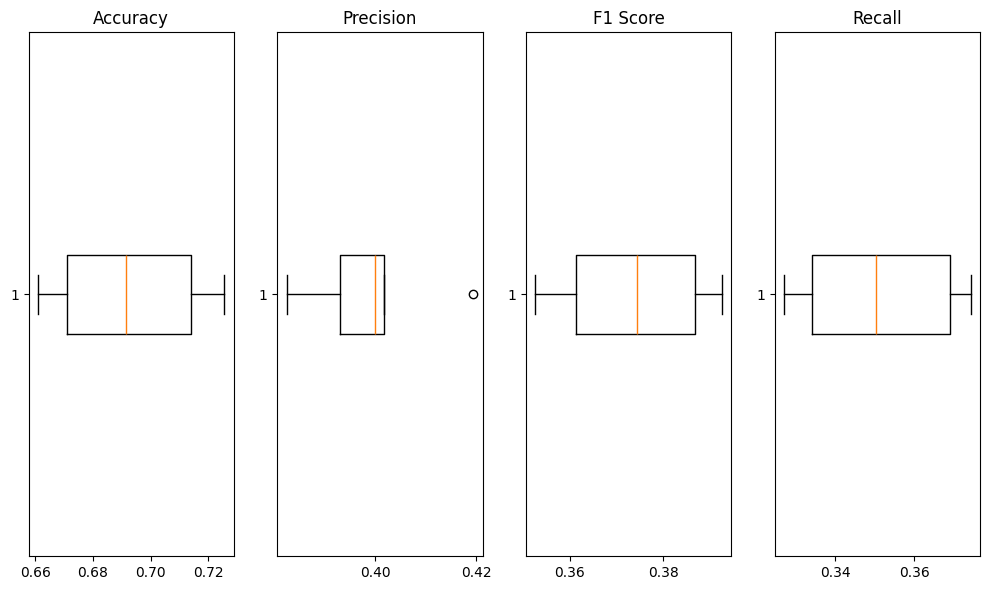

In [34]:
#plotting the cross validatio scores for each fold
plt.figure(figsize=(10,6))

#Accuracy plot
plt.subplot(1,4,1)
plt.boxplot([cv_scores],vert=False)
plt.title('Accuracy')

# Precision plot
plt.subplot(1,4,2)
plt.boxplot([precision_scores],vert=False)
plt.title('Precision')

# F1 Score plot
plt.subplot(1,4,3)
plt.boxplot([f1_scores],vert=False)
plt.title('F1 Score')

# Recall plot
plt.subplot(1,4,4)
plt.boxplot([recall_scores],vert=False)
plt.title('Recall')

plt.tight_layout()
plt.show()

# Summary

Applying cross-validation resulted in lower performance compared to using a single train-test split, there are several potential reasons for this discrepancy.
1. Check for Overfitting: Single train-test split may have led to overfitting. Cross-validation gives a more reliable estimate.
2. Ensure Proper Cross-Validation Setup: Use StratifiedKFold for imbalanced classes and more folds (e.g., 5 or 10).
3. Balance Class Distribution: Address class imbalance using SMOTE, undersampling, or class weighting.
4. Tune Hyperparameters: Ensure you're using the best model parameters by performing hyperparameter tuning.
5. Check Model Complexity: Avoid overly complex models (e.g., very deep decision trees) that overfit.
6. Evaluate Multiple Metrics: Don't rely on accuracy alone-use metrics like precision, recall, and F1-score.

In [35]:
jupyter nbconvert --ClearMetadataPreprocessor.enabled=True --inplace Decision_Tree.ipynb

SyntaxError: invalid syntax (366216303.py, line 1)